In [1]:
import pandas as pd
import torch
import numpy as np
from cgmvae import*
from torch.nn import functional as F
import matplotlib.pyplot as plt
from collections import Counter

In [2]:
# load original input data
# actually we don't really need to do this unless we're interested in accuracy of reconstruction too, but we don't necessarily need to be 
# load latent variables 
latent_features_train = pd.read_csv('/Users/racheliritani/Desktop/AD Project/mm-vae/cfc_pred/shap_analysis/train_df.csv')
latent_features_train

,LV1,LV2,LV3,LV4,LV5,mouse_ids,Diet,Mouse.ID,CFC.24mo.Average
0,1.648254,1.558364,1.450668,1.713205,1.723632,DO-1D-3168,1D,DO-1D-3168,-0.820451
1,-0.794890,-1.137012,-1.105946,-0.938151,-0.875722,DO-40-2083,40,DO-40-2083,0.780704
2,-0.348093,-0.264138,-0.208897,-0.409450,-0.600421,DO-20-1186,20,DO-20-1186,0.452638
3,0.956853,1.063802,1.653756,1.514652,1.608262,DO-1D-3059,1D,DO-1D-3059,1.698389
4,1.407127,1.454008,1.323928,1.397264,1.267337,DO-40-2002,40,DO-40-2002,-0.582971
...,...,...,...,...,...,...,...,...,...
398,-0.890301,-0.859367,-0.897388,-0.965282,-0.967811,DO-1D-3185,1D,DO-1D-3185,-1.763434
399,-0.481943,-0.825826,-0.808517,-0.631954,-0.711390,DO-2D-4058,2D,DO-2D-4058,0.951265
400,1.344620,1.542254,1.234269,1.474108,1.414498,DO-20-1053,20,DO-20-1053,-0.787807
401,0.919085,0.931402,1.518434,1.483853,1.381329,DO-20-1044,20,DO-20-1044,1.624125


In [3]:
data_with_cfc_labels = pd.read_csv('/Users/racheliritani/Desktop/AD Project/VAE-work/c-gmvae/data_with_cfc_5bins.csv')
data_with_cfc_labels = data_with_cfc_labels[['MouseID', 'cfc_bin']]
data_with_cfc_labels

,MouseID,cfc_bin
0,DO-40-2162,0
1,DO-40-2179,1
2,DO-40-2181,1
3,DO-40-2187,2
4,DO-40-2099,1
...,...,...
499,DO-2D-4007,1
500,DO-1D-3030,1
501,DO-20-1021,0
502,DO-AL-0002,2


In [4]:
saved_model_path = '/Users/racheliritani/Desktop/AD Project/mm-vae/results_DIET/CGMVAE_cfc_cond_5bins_5dim/saved_model_epoch5000.pth'

In [5]:
accelerator = True 

if accelerator:
    device = torch.device("mps")
else:
    device = torch.device("cpu")

In [6]:
#vae = CGMVAE()
vae = torch.load(saved_model_path, map_location=device)
vae.to(device)
vae.eval()

CGMVAE(
  (label): Embedding(5, 1)
  (fc1): Linear(in_features=37, out_features=16, bias=True)
  (bn1): BatchNorm1d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc21): Linear(in_features=16, out_features=25, bias=True)
  (fc22): Linear(in_features=16, out_features=25, bias=True)
  (fc3): Linear(in_features=6, out_features=16, bias=True)
  (bn3): BatchNorm1d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc4): Linear(in_features=16, out_features=36, bias=True)
)

## Doing analysis with LV5 conditonal label 0

In [97]:
mouse_ids_0 = data_with_cfc_labels[data_with_cfc_labels['cfc_bin'] == 0]['MouseID'].tolist()
latent_features_train_0 = latent_features_train[latent_features_train['Mouse.ID'].isin(mouse_ids_0)]
latent_features_train_0 = latent_features_train_0[['LV1', 'LV2', 'LV3', 'LV4', 'LV5']]
latent_features_train_0

,LV1,LV2,LV3,LV4,LV5
13,-0.893698,-0.720176,-0.866757,-0.823112,-1.094731
14,-1.622135,-1.356036,-1.420345,-1.495535,-1.267595
23,-0.957110,-0.818695,-0.948691,-0.993643,-0.997910
25,-1.577005,-1.315113,-1.407930,-1.409376,-1.314672
30,-1.276818,-1.093347,-1.127115,-1.167925,-0.975741
...,...,...,...,...,...
388,-1.436359,-1.235382,-1.249746,-1.297314,-0.932213
389,-1.141634,-0.943330,-0.982594,-1.051950,-0.920841
390,-1.327842,-1.144189,-1.166487,-1.188210,-1.019409
394,-1.513083,-1.272883,-1.293408,-1.326203,-1.131958


In [98]:
latent_features_train_mean_0 = latent_features_train_0.mean()
latent_features_train_mean_0

LV1   -1.348009
LV2   -1.133437
LV3   -1.187552
LV4   -1.229302
LV5   -1.090288
dtype: float64

In [99]:
min(latent_features_train_0['LV1']), max(latent_features_train_0['LV1'])

(-1.6601600773244354, -0.2810834585668674)

In [100]:
lv_traversal_values_0 = [-2, -1.5, -1, -0.5, 0]
latent_features_train_neg2_0 = latent_features_train_mean_0.copy()
latent_features_train_neg2_0.iloc[0] = lv_traversal_values_0[0]
latent_features_train_neg1_0 = latent_features_train_mean_0.copy()
latent_features_train_neg1_0.iloc[0] = lv_traversal_values_0[1]
latent_features_train_zero_0 = latent_features_train_mean_0.copy()
latent_features_train_zero_0.iloc[0] = lv_traversal_values_0[2]
latent_features_train_one_0 = latent_features_train_mean_0.copy()
latent_features_train_one_0.iloc[0] = lv_traversal_values_0[3]
latent_features_train_two_0 = latent_features_train_mean_0.copy()
latent_features_train_two_0.iloc[0] = lv_traversal_values_0[4]

In [101]:
stacked_data_input_0 = np.vstack((latent_features_train_neg2_0, latent_features_train_neg1_0, latent_features_train_zero_0, latent_features_train_one_0, latent_features_train_two_0))
stacked_data_input_0

array([[-2.        , -1.13343743, -1.18755181, -1.22930228, -1.09028788],
       [-1.5       , -1.13343743, -1.18755181, -1.22930228, -1.09028788],
       [-1.        , -1.13343743, -1.18755181, -1.22930228, -1.09028788],
       [-0.5       , -1.13343743, -1.18755181, -1.22930228, -1.09028788],
       [ 0.        , -1.13343743, -1.18755181, -1.22930228, -1.09028788]])

In [103]:
z_traversal_0 = torch.tensor(stacked_data_input_0, dtype=torch.float32).to(device)
#y_labels = torch.tensor(np.ones(5), dtype=torch.long).to(device)
y_labels_0 = torch.tensor(np.zeros(5), dtype=torch.long).to(device)

## Prepare data for transversing LV5 with conditional label 1

In [104]:
mouse_ids_1 = data_with_cfc_labels[data_with_cfc_labels['cfc_bin'] == 1]['MouseID'].tolist()
latent_features_train_1 = latent_features_train[latent_features_train['Mouse.ID'].isin(mouse_ids_1)]
latent_features_train_1 = latent_features_train_1[['LV1', 'LV2', 'LV3', 'LV4', 'LV5']]
latent_features_train_1

,LV1,LV2,LV3,LV4,LV5
0,1.648254,1.558364,1.450668,1.713205,1.723632
4,1.407127,1.454008,1.323928,1.397264,1.267337
15,1.219892,0.858839,0.811899,0.836143,0.712234
19,1.642225,1.663701,1.346894,1.761315,1.741227
21,1.510944,1.577664,1.146596,1.492334,1.343644
...,...,...,...,...,...
385,1.290042,1.164315,0.996189,1.291856,1.241618
387,1.512038,1.343424,1.239869,1.575708,1.555214
393,1.460973,1.360372,1.296377,1.578111,1.540010
400,1.344620,1.542254,1.234269,1.474108,1.414498


In [105]:
latent_features_train_mean_1 = latent_features_train_1.mean()
latent_features_train_mean_1

LV1    1.338759
LV2    1.337852
LV3    1.042993
LV4    1.238350
LV5    1.175304
dtype: float64

In [106]:
min(latent_features_train_1['LV1']), max(latent_features_train_1['LV1'])

(-0.3167700917757454, 2.2095611997253943)

In [107]:
lv_traversal_values_1 = [-0.5, .25, 1, 1.75, 2.5]
latent_features_train_neg2_1 = latent_features_train_mean_1.copy()
latent_features_train_neg2_1.iloc[0] = lv_traversal_values_1[0]
latent_features_train_neg1_1 = latent_features_train_mean_1.copy()
latent_features_train_neg1_1.iloc[0] = lv_traversal_values_1[1]
latent_features_train_zero_1 = latent_features_train_mean_1.copy()
latent_features_train_zero_1.iloc[0] = lv_traversal_values_1[2]
latent_features_train_one_1 = latent_features_train_mean_1.copy()
latent_features_train_one_1.iloc[0] = lv_traversal_values_1[3]
latent_features_train_two_1 = latent_features_train_mean_1.copy()
latent_features_train_two_1.iloc[0] = lv_traversal_values_1[4]

In [108]:
stacked_data_input_1 = np.vstack((latent_features_train_neg2_1, latent_features_train_neg1_1, latent_features_train_zero_1, latent_features_train_one_1, latent_features_train_two_1))
stacked_data_input_1

array([[-0.5       ,  1.33785187,  1.04299338,  1.23834988,  1.17530418],
       [ 0.25      ,  1.33785187,  1.04299338,  1.23834988,  1.17530418],
       [ 1.        ,  1.33785187,  1.04299338,  1.23834988,  1.17530418],
       [ 1.75      ,  1.33785187,  1.04299338,  1.23834988,  1.17530418],
       [ 2.5       ,  1.33785187,  1.04299338,  1.23834988,  1.17530418]])

In [109]:
z_traversal_1 = torch.tensor(stacked_data_input_1, dtype=torch.float32).to(device)
y_labels_1 = torch.tensor(np.ones(5), dtype=torch.long).to(device)

# Prepare data for traversing LV5 with conditional label 2

In [110]:
mouse_ids_2 = data_with_cfc_labels[data_with_cfc_labels['cfc_bin'] == 2]['MouseID'].tolist()
latent_features_train_2 = latent_features_train[latent_features_train['Mouse.ID'].isin(mouse_ids_2)]
latent_features_train_2 = latent_features_train_2[['LV1', 'LV2', 'LV3', 'LV4', 'LV5']]
latent_features_train_2

,LV1,LV2,LV3,LV4,LV5
2,-0.348093,-0.264138,-0.208897,-0.409450,-0.600421
5,0.035996,0.163485,0.447772,0.348364,0.387066
7,0.014778,-0.089215,0.067121,-0.068191,-0.177578
10,-0.055891,-0.020498,0.081582,-0.034955,-0.152137
11,0.142019,0.236467,0.418668,0.282368,0.217389
...,...,...,...,...,...
370,-0.149577,-0.281372,-0.351628,-0.525232,-0.632906
380,-0.082595,-0.111938,0.116845,-0.013294,0.003919
382,-0.117836,-0.044868,-0.031371,-0.131411,-0.181905
395,-0.126171,-0.197896,-0.105915,-0.251575,-0.388558


In [111]:
latent_features_train_mean_2 = latent_features_train_2.mean()
latent_features_train_mean_2

LV1   -0.110642
LV2   -0.064196
LV3    0.047799
LV4   -0.086370
LV5   -0.156310
dtype: float64

In [112]:
min(latent_features_train_2['LV1']), max(latent_features_train_2['LV1'])

(-0.5054427102850931, 0.27265744490611)

In [113]:
lv_traversal_values_2 = [-1, -0.6, -0.2, 0.2, 0.6]
latent_features_train_neg2_2 = latent_features_train_mean_2.copy()
latent_features_train_neg2_2.iloc[0] = lv_traversal_values_2[0]
latent_features_train_neg1_2 = latent_features_train_mean_2.copy()
latent_features_train_neg1_2.iloc[0] = lv_traversal_values_2[1]
latent_features_train_zero_2 = latent_features_train_mean_2.copy()
latent_features_train_zero_2.iloc[0] = lv_traversal_values_2[2]
latent_features_train_one_2 = latent_features_train_mean_2.copy()
latent_features_train_one_2.iloc[0] = lv_traversal_values_2[3]
latent_features_train_two_2 = latent_features_train_mean_2.copy()
latent_features_train_two_2.iloc[0] = lv_traversal_values_2[4]

In [114]:
stacked_data_input_2 = np.vstack((latent_features_train_neg2_2, latent_features_train_neg1_2, latent_features_train_zero_2, latent_features_train_one_2, latent_features_train_two_2))
stacked_data_input_2

array([[-1.        , -0.06419645,  0.0477987 , -0.08637038, -0.15630968],
       [-0.6       , -0.06419645,  0.0477987 , -0.08637038, -0.15630968],
       [-0.2       , -0.06419645,  0.0477987 , -0.08637038, -0.15630968],
       [ 0.2       , -0.06419645,  0.0477987 , -0.08637038, -0.15630968],
       [ 0.6       , -0.06419645,  0.0477987 , -0.08637038, -0.15630968]])

In [115]:
z_traversal_2 = torch.tensor(stacked_data_input_2, dtype=torch.float32).to(device)
y_labels_2 = torch.tensor(np.ones(5) * 2, dtype=torch.long).to(device)

# Prepare data for traversing LV5 with conditional label 3

In [116]:
mouse_ids_3 = data_with_cfc_labels[data_with_cfc_labels['cfc_bin'] == 3]['MouseID'].tolist()
latent_features_train_3 = latent_features_train[latent_features_train['Mouse.ID'].isin(mouse_ids_3)]
latent_features_train_3 = latent_features_train_3[['LV1', 'LV2', 'LV3', 'LV4', 'LV5']]
latent_features_train_3

,LV1,LV2,LV3,LV4,LV5
1,-0.794890,-1.137012,-1.105946,-0.938151,-0.875722
6,-0.577949,-0.922756,-0.905568,-0.737581,-0.774369
8,-0.475260,-0.876369,-0.796801,-0.632104,-0.687762
16,-0.541115,-0.852015,-0.859629,-0.709350,-0.757850
26,-0.231526,-0.615353,-0.641229,-0.464054,-0.702358
...,...,...,...,...,...
377,-0.056066,-0.411063,-0.400782,-0.268354,-0.583646
379,-0.888835,-1.038130,-1.258650,-1.086238,-1.199128
386,-0.406040,-0.840978,-0.788157,-0.581329,-0.696034
397,-0.521439,-0.892044,-0.884971,-0.669015,-0.744653


In [117]:
latent_features_train_mean_3 = latent_features_train_3.mean()
latent_features_train_mean_3

LV1   -0.560520
LV2   -0.896860
LV3   -0.899536
LV4   -0.714436
LV5   -0.797925
dtype: float64

In [118]:
min(latent_features_train_3['LV1']), max(latent_features_train_3['LV1'])

(-0.9598900514715052, -0.0560662500637446)

In [119]:
lv_traversal_values_3 = [-1, -0.75, -0.5, -0.25, 0]
latent_features_train_neg2_3 = latent_features_train_mean_3.copy()
latent_features_train_neg2_3.iloc[0] = lv_traversal_values_3[0]
latent_features_train_neg1_3 = latent_features_train_mean_3.copy()
latent_features_train_neg1_3.iloc[0] = lv_traversal_values_3[1]
latent_features_train_zero_3 = latent_features_train_mean_3.copy()
latent_features_train_zero_3.iloc[0] = lv_traversal_values_3[2]
latent_features_train_one_3 = latent_features_train_mean_3.copy()
latent_features_train_one_3.iloc[0] = lv_traversal_values_3[3]
latent_features_train_two_3 = latent_features_train_mean_3.copy()
latent_features_train_two_3.iloc[0] = lv_traversal_values_3[4]

In [120]:
stacked_data_input_3 = np.vstack((latent_features_train_neg2_3, latent_features_train_neg1_3, latent_features_train_zero_3, latent_features_train_one_3, latent_features_train_two_3))
stacked_data_input_3

array([[-1.        , -0.89686036, -0.89953568, -0.71443556, -0.79792473],
       [-0.75      , -0.89686036, -0.89953568, -0.71443556, -0.79792473],
       [-0.5       , -0.89686036, -0.89953568, -0.71443556, -0.79792473],
       [-0.25      , -0.89686036, -0.89953568, -0.71443556, -0.79792473],
       [ 0.        , -0.89686036, -0.89953568, -0.71443556, -0.79792473]])

In [121]:
z_traversal_3 = torch.tensor(stacked_data_input_3, dtype=torch.float32).to(device)
y_labels_3 = torch.tensor(np.ones(5) * 3, dtype=torch.long).to(device)

# Prepare data for traversing LV5 with conditional label 4

In [122]:
mouse_ids_4 = data_with_cfc_labels[data_with_cfc_labels['cfc_bin'] == 4]['MouseID'].tolist()
latent_features_train_4 = latent_features_train[latent_features_train['Mouse.ID'].isin(mouse_ids_4)]
latent_features_train_4 = latent_features_train_4[['LV1', 'LV2', 'LV3', 'LV4', 'LV5']]

In [123]:
latent_features_train_mean_4 = latent_features_train_4.mean()
latent_features_train_mean_4

LV1    0.930291
LV2    1.044031
LV3    1.538322
LV4    1.168438
LV5    1.401014
dtype: float64

In [124]:
min(latent_features_train_4['LV1']), max(latent_features_train_4['LV1'])

(0.7438996946974415, 1.0426512716125125)

In [125]:
lv_traversal_values_4 = [0.5, 0.7, 0.9, 1.1, 1.3]
latent_features_train_neg2_4 = latent_features_train_mean_4.copy()
latent_features_train_neg2_4.iloc[0] = lv_traversal_values_4[0]
latent_features_train_neg1_4 = latent_features_train_mean_4.copy()
latent_features_train_neg1_4.iloc[0] = lv_traversal_values_4[1]
latent_features_train_zero_4 = latent_features_train_mean_4.copy()
latent_features_train_zero_4.iloc[0] = lv_traversal_values_4[2]
latent_features_train_one_4 = latent_features_train_mean_4.copy()
latent_features_train_one_4.iloc[0] = lv_traversal_values_4[3]
latent_features_train_two_4 = latent_features_train_mean_4.copy()
latent_features_train_two_4.iloc[0] = lv_traversal_values_4[4]

In [126]:
stacked_data_input_4 = np.vstack((latent_features_train_neg2_4, latent_features_train_neg1_4, latent_features_train_zero_4, latent_features_train_one_4, latent_features_train_two_4))
stacked_data_input_4

array([[0.5       , 1.0440314 , 1.53832194, 1.16843782, 1.40101444],
       [0.7       , 1.0440314 , 1.53832194, 1.16843782, 1.40101444],
       [0.9       , 1.0440314 , 1.53832194, 1.16843782, 1.40101444],
       [1.1       , 1.0440314 , 1.53832194, 1.16843782, 1.40101444],
       [1.3       , 1.0440314 , 1.53832194, 1.16843782, 1.40101444]])

In [127]:
z_traversal_4 = torch.tensor(stacked_data_input_4, dtype=torch.float32).to(device)
y_labels_4 = torch.tensor(np.ones(5) * 4, dtype=torch.long).to(device)

# Get mean and std for unstandardizing 

In [128]:
# Using training data to extract the mean and standardizing for our "unstandardizing"
cgmvae_train_data = pd.read_csv('/Users/racheliritani/Desktop/AD Project/VAE-work/c-gmvae/train_data_with_cfc_5bins.csv')
cgmvae_train_data_features = cgmvae_train_data.iloc[:, 1:-5]
cgmvae_train_data_features

,Generation,SurvDays,Y1A_BW_BW,Y2A_BW_BW,Y3A_BW_BW,Y1_Glu.F_Glucose,Y2_Glu.F_Glucose,Y3_Glu.F_Glucose,Y1_Echo_BPM,Y2_Echo_BPM,...,Y1_Wheel_AvgDistLFC,Y2_Wheel_AvgDistLFC,Y3_Wheel_AvgDistLFC,Y1A_Grip_All,Y2A_Grip_All,Y3A_Grip_All,Y1A_Frailty_FrailtyAdj,Y2A_Frailty_FrailtyAdj,Y3A_Frailty_FrailtyAdj,Diet_num
0,28,1557,30.432753,23.594599,23.529931,161.043852,71.901384,69.226421,495.841743,501.256947,...,1.822722,0.348339,0.747802,291.910043,181.741358,208.833723,0.183285,0.231782,0.235033,1
1,28,1520,25.977819,29.254446,30.242503,127.747193,85.358891,71.148922,466.210754,464.586935,...,0.999795,1.146192,0.924488,145.679543,223.139358,208.833223,0.106295,0.174654,0.216059,1
2,26,1638,24.242912,23.626717,22.912834,166.520150,72.692867,59.960123,464.789558,574.873297,...,1.044482,1.776962,2.179152,261.760471,173.953709,153.357082,0.110173,0.155822,0.285573,1
3,28,1406,24.467278,25.248257,23.109300,164.713839,87.471495,73.518078,467.014292,562.596065,...,1.680998,0.523920,0.894472,172.757669,113.888445,116.420115,0.104875,0.186652,0.231596,1
4,27,1463,27.809766,25.863157,26.732366,158.296170,79.935074,89.493029,460.859469,452.538921,...,1.255751,1.035345,0.902079,232.284376,238.633857,250.015922,0.106669,0.199779,0.104132,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
398,22,825,26.553743,38.871831,38.162515,88.072095,132.803099,261.476515,457.706405,636.333799,...,1.327876,-0.250994,-2.736010,144.637287,200.397753,58.352082,0.301015,0.221042,0.555556,5
399,22,811,29.286695,34.668011,28.691245,145.238675,123.017597,261.476515,487.109521,459.643424,...,0.292768,1.503025,-2.736010,122.680287,147.980753,58.352082,0.301015,0.193995,0.555556,4
400,22,790,20.955567,32.435192,67.590983,135.481563,148.935317,261.476515,471.297011,513.299191,...,-0.505758,2.390828,-2.736010,128.851073,144.305810,58.352082,0.301015,0.188242,0.555556,4
401,22,748,24.315156,29.916707,67.590983,139.326564,136.439061,261.476515,544.317015,474.787570,...,3.246833,0.934841,-2.736010,223.713073,138.051810,58.352082,0.301015,0.082493,0.555556,4


In [129]:
all_input_features = cgmvae_train_data_features.columns
all_input_features

Index(['Generation', 'SurvDays', 'Y1A_BW_BW', 'Y2A_BW_BW', 'Y3A_BW_BW',
       'Y1_Glu.F_Glucose', 'Y2_Glu.F_Glucose', 'Y3_Glu.F_Glucose',
       'Y1_Echo_BPM', 'Y2_Echo_BPM', 'Y3_Echo_BPM', 'Y1_Echo_CardiacOutput',
       'Y2_Echo_CardiacOutput', 'Y3_Echo_CardiacOutput', 'Y1_CBC_Hgb',
       'Y2_CBC_Hgb', 'Y3_CBC_Hgb', 'Y1_Rotarod_Mean', 'Y2_Rotarod_Mean',
       'Y3_Rotarod_Mean', 'Y1_AS_MeanLog', 'Y2_AS_MeanLog', 'Y3_AS_MeanLog',
       'Y1_Wheel_AvgSpeedLFC', 'Y2_Wheel_AvgSpeedLFC', 'Y3_Wheel_AvgSpeedLFC',
       'Y1_Wheel_AvgDistLFC', 'Y2_Wheel_AvgDistLFC', 'Y3_Wheel_AvgDistLFC',
       'Y1A_Grip_All', 'Y2A_Grip_All', 'Y3A_Grip_All',
       'Y1A_Frailty_FrailtyAdj', 'Y2A_Frailty_FrailtyAdj',
       'Y3A_Frailty_FrailtyAdj', 'Diet_num'],
      dtype='object')

In [130]:
col_means = cgmvae_train_data_features.mean()
col_means.shape

(36,)

In [131]:
col_std = cgmvae_train_data_features.std()
col_std.shape

(36,)

# Run decoding on each conditional feature 

In [132]:
with torch.no_grad():
    # y_emb = vae.label(y_labels)

    # x = torch.cat((z_traversal, y_emb), dim=1)

    # h3_linear = vae.fc3(x)
    # h3_bn = vae.bn3(h3_linear)
    # h3_act = F.tanh(h3_bn)
    
    # vae.fc4(h3_act)
    reconstructions_standardized_0 = vae.decode(z_traversal_0, y_labels_0)
    reconstructions_standardized_1 = vae.decode(z_traversal_1, y_labels_1)
    reconstructions_standardized_2 = vae.decode(z_traversal_2, y_labels_2)
    reconstructions_standardized_3 = vae.decode(z_traversal_3, y_labels_3)
    reconstructions_standardized_4 = vae.decode(z_traversal_4, y_labels_4)

In [133]:
col_means_tensor = torch.tensor(col_means.values, dtype=torch.float32).to(device)
col_std_tensor = torch.tensor(col_std.values, dtype=torch.float32).to(device)

# Doing analysis for LV5 traversal with conditional label 0

In [134]:
unstandardized_data_tensor_0 = reconstructions_standardized_0 * col_std_tensor
unstandardized_data_tensor_0 = unstandardized_data_tensor_0 + col_means_tensor

In [135]:
reconstructions_unstandardized_df_0 = pd.DataFrame(unstandardized_data_tensor_0.cpu(), columns=all_input_features)
reconstructions_unstandardized_df_0

,Generation,SurvDays,Y1A_BW_BW,Y2A_BW_BW,Y3A_BW_BW,Y1_Glu.F_Glucose,Y2_Glu.F_Glucose,Y3_Glu.F_Glucose,Y1_Echo_BPM,Y2_Echo_BPM,...,Y1_Wheel_AvgDistLFC,Y2_Wheel_AvgDistLFC,Y3_Wheel_AvgDistLFC,Y1A_Grip_All,Y2A_Grip_All,Y3A_Grip_All,Y1A_Frailty_FrailtyAdj,Y2A_Frailty_FrailtyAdj,Y3A_Frailty_FrailtyAdj,Diet_num
0,24.148823,1012.476379,29.258968,39.657940,37.106461,192.872101,153.196259,159.311172,542.886902,538.825623,...,1.973173,1.440174,-1.145443,170.402084,177.434708,133.933899,0.188133,0.222883,0.306988,3.382691
1,24.162788,1012.190552,29.249882,39.613007,37.017540,192.709000,153.004486,159.245316,542.386719,538.691040,...,1.967137,1.440376,-1.159222,170.981201,177.514526,133.923431,0.188381,0.222546,0.307265,3.380258
2,24.176884,1011.907227,29.240255,39.566681,36.926102,192.539139,152.806229,159.176025,541.873047,538.552551,...,1.960939,1.440571,-1.173212,171.571304,177.596268,133.912003,0.188641,0.222201,0.307548,3.377760
3,24.191090,1011.626343,29.230078,39.519054,36.832340,192.362732,152.601898,159.103699,541.346741,538.410339,...,1.954587,1.440758,-1.187389,172.171387,177.679855,133.899429,0.188910,0.221849,0.307838,3.375210
4,24.205387,1011.347656,29.219332,39.470242,36.736492,192.180115,152.391983,159.028824,540.808899,538.264771,...,1.948089,1.440936,-1.201728,172.780426,177.765244,133.885483,0.189188,0.221489,0.308134,3.372622


In [136]:
reconstructions_standardized_df_0 = pd.DataFrame(reconstructions_standardized_0.cpu(), columns=all_input_features)
reconstructions_standardized_df_0

,Generation,SurvDays,Y1A_BW_BW,Y2A_BW_BW,Y3A_BW_BW,Y1_Glu.F_Glucose,Y2_Glu.F_Glucose,Y3_Glu.F_Glucose,Y1_Echo_BPM,Y2_Echo_BPM,...,Y1_Wheel_AvgDistLFC,Y2_Wheel_AvgDistLFC,Y3_Wheel_AvgDistLFC,Y1A_Grip_All,Y2A_Grip_All,Y3A_Grip_All,Y1A_Frailty_FrailtyAdj,Y2A_Frailty_FrailtyAdj,Y3A_Frailty_FrailtyAdj,Diet_num
0,-0.425503,0.026754,0.659436,0.796075,0.129078,1.027734,0.711723,0.106729,0.733086,0.765296,...,0.193610,0.095790,0.152709,-0.451219,0.242520,0.181290,0.476495,0.611484,-0.006169,0.409590
1,-0.419395,0.025135,0.657526,0.790815,0.122572,1.023246,0.706574,0.105804,0.723268,0.762559,...,0.189039,0.095921,0.145523,-0.437494,0.244710,0.181068,0.479686,0.604155,-0.004167,0.407822
2,-0.413229,0.023530,0.655504,0.785392,0.115882,1.018571,0.701250,0.104830,0.713184,0.759740,...,0.184345,0.096048,0.138227,-0.423508,0.246953,0.180825,0.483014,0.596640,-0.002121,0.406008
3,-0.407015,0.021938,0.653365,0.779816,0.109021,1.013717,0.695763,0.103814,0.702853,0.756848,...,0.179534,0.096170,0.130834,-0.409286,0.249247,0.180558,0.486470,0.588954,-0.000029,0.404155
4,-0.400761,0.020359,0.651107,0.774102,0.102008,1.008692,0.690126,0.102763,0.692297,0.753886,...,0.174612,0.096285,0.123356,-0.394852,0.251591,0.180263,0.490040,0.581109,0.002113,0.402275


In [137]:
z_min = reconstructions_standardized_df_0.iloc[0]
z_max = reconstructions_standardized_df_0.iloc[-1]
difference_lv5_0 = np.abs(z_max - z_min)
difference_lv5_0_ranked = difference_lv5_0.sort_values(ascending=False)
difference_lv5_0_ranked.head(10)

Y1A_Grip_All              0.056367
Y2_AS_MeanLog             0.046558
Y1_Echo_BPM               0.040789
Y3_AS_MeanLog             0.033259
Y3_Wheel_AvgSpeedLFC      0.033056
Y3_CBC_Hgb                0.031412
Y2A_Frailty_FrailtyAdj    0.030375
Y3_Wheel_AvgDistLFC       0.029353
Y3A_BW_BW                 0.027070
Generation                0.024742
dtype: float32

In [138]:
difference_lv5_0_test = np.abs(reconstructions_standardized_df_0.iloc[-1, [0, 1]] - reconstructions_standardized_df_0.iloc[0, [0, 1]])
difference_lv5_0_test = pd.concat([difference_lv5_0_test, np.abs(reconstructions_standardized_df_0.iloc[-1, [-1]] - reconstructions_standardized_df_0.iloc[0, [-1]])])
difference_lv5_0_test
max_data = reconstructions_standardized_df_0.iloc[-1, 2:-1]
min_data = reconstructions_standardized_df_0.iloc[0, 2:-1]

In [139]:
len(max_data) / 3

11.0

In [140]:
max_data

Y1A_BW_BW                 0.651107
Y2A_BW_BW                 0.774102
Y3A_BW_BW                 0.102008
Y1_Glu.F_Glucose          1.008692
Y2_Glu.F_Glucose          0.690126
Y3_Glu.F_Glucose          0.102763
Y1_Echo_BPM               0.692297
Y2_Echo_BPM               0.753886
Y3_Echo_BPM               0.010979
Y1_Echo_CardiacOutput     0.944364
Y2_Echo_CardiacOutput     0.666881
Y3_Echo_CardiacOutput    -0.056709
Y1_CBC_Hgb                0.237123
Y2_CBC_Hgb               -0.848129
Y3_CBC_Hgb                0.064600
Y1_Rotarod_Mean          -0.595148
Y2_Rotarod_Mean          -0.883786
Y3_Rotarod_Mean          -0.150504
Y1_AS_MeanLog             0.034077
Y2_AS_MeanLog             0.049760
Y3_AS_MeanLog            -0.282484
Y1_Wheel_AvgSpeedLFC      0.200236
Y2_Wheel_AvgSpeedLFC      0.098747
Y3_Wheel_AvgSpeedLFC      0.151042
Y1_Wheel_AvgDistLFC       0.174612
Y2_Wheel_AvgDistLFC       0.096285
Y3_Wheel_AvgDistLFC       0.123356
Y1A_Grip_All             -0.394852
Y2A_Grip_All        

In [141]:
feature_names = max_data.index.tolist()
max_data_np = max_data.to_numpy()
min_data_np = min_data.to_numpy()
for feature in range(int(len(max_data) / 3)): 
    feature_name = feature_names[feature*3]
    feature_name = feature_name.split('_', 1)[1]
    max_vector = max_data_np[feature:feature+3]
    min_vector = min_data_np[feature:feature+3]
    diff = np.abs(max_vector-min_vector)
    sum = np.linalg.norm(diff)
    difference_lv5_0_test = pd.concat([difference_lv5_0_test, pd.Series(data=sum, index=[feature_name])])

In [142]:
print(difference_lv5_0_test)

Generation            0.024742
SurvDays              0.006395
Diet_num              0.007315
BW_BW                 0.035846
Glu.F_Glucose         0.039726
Echo_BPM              0.039519
Echo_CardiacOutput    0.029064
CBC_Hgb               0.046324
Rotarod_Mean          0.042541
AS_MeanLog            0.046326
Wheel_AvgSpeedLFC     0.022553
Wheel_AvgDistLFC      0.027041
Grip_All              0.024650
Frailty_FrailtyAdj    0.025066
dtype: float32


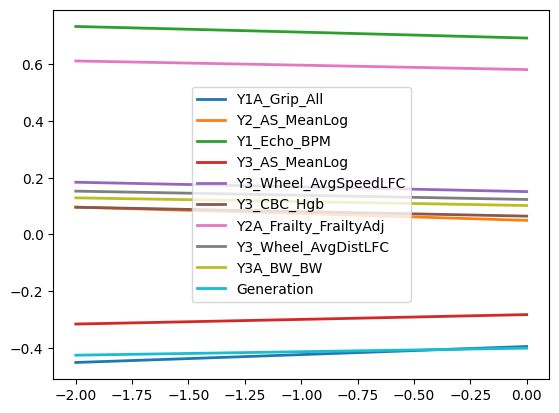

In [143]:
for col_name in difference_lv5_0_ranked.head(10).index.tolist(): 
    plt.plot(
        lv_traversal_values_0, 
        reconstructions_standardized_df_0[col_name], 
        label=col_name, 
        linewidth=2
    )
    plt.legend()

# Doing analysis for LV5 traversal with conditional label 1

In [144]:
unstandardized_data_tensor_1 = reconstructions_standardized_1 * col_std_tensor
unstandardized_data_tensor_1 = unstandardized_data_tensor_1 + col_means_tensor

In [145]:
reconstructions_unstandardized_df_1 = pd.DataFrame(unstandardized_data_tensor_1.cpu(), columns=all_input_features)
reconstructions_unstandardized_df_1

,Generation,SurvDays,Y1A_BW_BW,Y2A_BW_BW,Y3A_BW_BW,Y1_Glu.F_Glucose,Y2_Glu.F_Glucose,Y3_Glu.F_Glucose,Y1_Echo_BPM,Y2_Echo_BPM,...,Y1_Wheel_AvgDistLFC,Y2_Wheel_AvgDistLFC,Y3_Wheel_AvgDistLFC,Y1A_Grip_All,Y2A_Grip_All,Y3A_Grip_All,Y1A_Frailty_FrailtyAdj,Y2A_Frailty_FrailtyAdj,Y3A_Frailty_FrailtyAdj,Diet_num
0,22.152105,1143.160889,27.077276,32.093372,25.409958,162.132202,115.419189,115.317917,498.923859,517.317993,...,1.500697,1.324664,-0.321834,147.402634,172.502777,135.694244,0.266258,0.198640,0.254382,2.568548
1,22.184250,1142.342285,27.114803,32.193932,25.534039,162.390884,115.733360,115.726364,498.584991,517.460266,...,1.496723,1.319756,-0.328937,147.983597,172.792038,135.713898,0.265887,0.199017,0.255428,2.574761
2,22.213741,1141.563354,27.146152,32.292213,25.658821,162.620377,116.043274,116.135262,498.278534,517.605164,...,1.492963,1.315099,-0.334384,148.501312,173.072342,135.714951,0.265504,0.199396,0.256465,2.581596
3,22.240593,1140.829468,27.171267,32.388092,25.784023,162.819458,116.348091,116.542870,498.001587,517.751648,...,1.489387,1.310679,-0.338135,148.956177,173.344193,135.698318,0.265108,0.199777,0.257494,2.589029
4,22.264818,1140.146606,27.190105,32.481445,25.909359,162.986908,116.646927,116.947281,497.750946,517.898682,...,1.485966,1.306480,-0.340146,149.348694,173.608078,135.665161,0.264701,0.200159,0.258509,2.597033


In [146]:
reconstructions_standardized_df_1 = pd.DataFrame(reconstructions_standardized_1.cpu(), columns=all_input_features)
reconstructions_standardized_df_1

,Generation,SurvDays,Y1A_BW_BW,Y2A_BW_BW,Y3A_BW_BW,Y1_Glu.F_Glucose,Y2_Glu.F_Glucose,Y3_Glu.F_Glucose,Y1_Echo_BPM,Y2_Echo_BPM,...,Y1_Wheel_AvgDistLFC,Y2_Wheel_AvgDistLFC,Y3_Wheel_AvgDistLFC,Y1A_Grip_All,Y2A_Grip_All,Y3A_Grip_All,Y1A_Frailty_FrailtyAdj,Y2A_Frailty_FrailtyAdj,Y3A_Frailty_FrailtyAdj,Diet_num
0,-1.298902,0.767192,0.200986,-0.089461,-0.726728,0.181873,-0.302692,-0.511274,-0.129883,0.327714,...,-0.164217,0.020704,0.582227,-0.996309,0.107172,0.218638,1.478755,0.083121,-0.386488,-0.181835
1,-1.284842,0.762554,0.208872,-0.077690,-0.717649,0.188992,-0.294256,-0.505537,-0.136535,0.330608,...,-0.167227,0.017514,0.578523,-0.982540,0.115110,0.219055,1.474004,0.091338,-0.378931,-0.177322
2,-1.271941,0.758140,0.215460,-0.066184,-0.708519,0.195307,-0.285934,-0.499793,-0.142550,0.333556,...,-0.170075,0.014486,0.575682,-0.970270,0.122802,0.219078,1.469081,0.099597,-0.371428,-0.172357
3,-1.260196,0.753982,0.220737,-0.054960,-0.699358,0.200784,-0.277748,-0.494067,-0.147987,0.336536,...,-0.172783,0.011613,0.573726,-0.959489,0.130263,0.218725,1.464002,0.107894,-0.363995,-0.166957
4,-1.249600,0.750113,0.224696,-0.044032,-0.690188,0.205392,-0.269724,-0.488386,-0.152907,0.339528,...,-0.175374,0.008884,0.572677,-0.950187,0.137505,0.218021,1.458783,0.116226,-0.356653,-0.161143


In [147]:
z_min = reconstructions_standardized_df_1.iloc[0]
z_max = reconstructions_standardized_df_1.iloc[-1]
difference_lv5_1 = np.abs(z_max - z_min)
difference_lv5_1_ranked = difference_lv5_1.sort_values(ascending=False)
difference_lv5_1_ranked.head(10)

Y2_Echo_CardiacOutput     0.054839
Generation                0.049302
Y1A_Grip_All              0.046122
Y2A_BW_BW                 0.045429
Y1_CBC_Hgb                0.037445
Y3A_BW_BW                 0.036540
Y2A_Frailty_FrailtyAdj    0.033106
Y2_Glu.F_Glucose          0.032968
Y2A_Grip_All              0.030333
Y3A_Frailty_FrailtyAdj    0.029835
dtype: float32

# Doing analysis for LV5 traversal with conditional label 2

In [148]:
unstandardized_data_tensor_2 = reconstructions_standardized_2 * col_std_tensor
unstandardized_data_tensor_2 = unstandardized_data_tensor_2 + col_means_tensor

In [149]:
reconstructions_unstandardized_df_2 = pd.DataFrame(unstandardized_data_tensor_2.cpu(), columns=all_input_features)
reconstructions_unstandardized_df_2

,Generation,SurvDays,Y1A_BW_BW,Y2A_BW_BW,Y3A_BW_BW,Y1_Glu.F_Glucose,Y2_Glu.F_Glucose,Y3_Glu.F_Glucose,Y1_Echo_BPM,Y2_Echo_BPM,...,Y1_Wheel_AvgDistLFC,Y2_Wheel_AvgDistLFC,Y3_Wheel_AvgDistLFC,Y1A_Grip_All,Y2A_Grip_All,Y3A_Grip_All,Y1A_Frailty_FrailtyAdj,Y2A_Frailty_FrailtyAdj,Y3A_Frailty_FrailtyAdj,Diet_num
0,22.798599,1107.257324,27.981956,33.944565,27.832754,170.419724,124.345787,126.160095,504.354614,522.719421,...,1.568891,1.366631,-0.682637,159.458969,174.746063,136.529388,0.251620,0.203992,0.270762,2.741608
1,22.810843,1106.856201,27.987648,33.959599,27.841677,170.435974,124.388969,126.281258,504.139282,522.740845,...,1.566286,1.366063,-0.689261,159.796814,174.845734,136.520233,0.251585,0.203999,0.271186,2.743546
2,22.822527,1106.461792,27.992287,33.974972,27.852196,170.449432,124.434326,126.405090,503.936096,522.764526,...,1.563783,1.365517,-0.695439,160.117218,174.943512,136.506790,0.251542,0.204011,0.271610,2.745653
3,22.833654,1106.074341,27.995876,33.990681,27.864296,170.460022,124.481781,126.531464,503.744659,522.790344,...,1.561378,1.364989,-0.701168,160.420380,175.039474,136.489105,0.251491,0.204028,0.272033,2.747927
4,22.844234,1105.694458,27.998415,34.006721,27.877954,170.467636,124.531242,126.660248,503.564514,522.818176,...,1.559065,1.364475,-0.706446,160.706467,175.133743,136.467285,0.251433,0.204049,0.272456,2.750366


In [150]:
reconstructions_standardized_df_2 = pd.DataFrame(reconstructions_standardized_2.cpu(), columns=all_input_features)
reconstructions_standardized_df_2

,Generation,SurvDays,Y1A_BW_BW,Y2A_BW_BW,Y3A_BW_BW,Y1_Glu.F_Glucose,Y2_Glu.F_Glucose,Y3_Glu.F_Glucose,Y1_Echo_BPM,Y2_Echo_BPM,...,Y1_Wheel_AvgDistLFC,Y2_Wheel_AvgDistLFC,Y3_Wheel_AvgDistLFC,Y1A_Grip_All,Y2A_Grip_All,Y3A_Grip_All,Y1A_Frailty_FrailtyAdj,Y2A_Frailty_FrailtyAdj,Y3A_Frailty_FrailtyAdj,Diet_num
0,-1.016115,0.563767,0.391091,0.127246,-0.549457,0.409919,-0.062989,-0.358967,-0.023280,0.437609,...,-0.112571,0.047985,0.394066,-0.710572,0.168735,0.236357,1.290972,0.199769,-0.268072,-0.056118
1,-1.010759,0.561495,0.392287,0.129006,-0.548805,0.410366,-0.061829,-0.357265,-0.027507,0.438044,...,-0.114544,0.047615,0.390611,-0.702565,0.171470,0.236163,1.290520,0.199928,-0.265006,-0.054710
2,-1.005649,0.559260,0.393262,0.130806,-0.548035,0.410736,-0.060611,-0.355525,-0.031496,0.438526,...,-0.116440,0.047260,0.387390,-0.694971,0.174153,0.235878,1.289967,0.200188,-0.261942,-0.053180
3,-1.000781,0.557065,0.394016,0.132645,-0.547150,0.411027,-0.059337,-0.353750,-0.035254,0.439051,...,-0.118261,0.046917,0.384402,-0.687786,0.176787,0.235502,1.289316,0.200549,-0.258881,-0.051527
4,-0.996153,0.554913,0.394550,0.134522,-0.546150,0.411237,-0.058009,-0.351941,-0.038790,0.439617,...,-0.120012,0.046583,0.381649,-0.681006,0.179374,0.235039,1.288569,0.201011,-0.255823,-0.049755


In [151]:
z_min = reconstructions_standardized_df_2.iloc[0]
z_max = reconstructions_standardized_df_2.iloc[-1]
difference_lv5_2 = np.abs(z_max - z_min)
difference_lv5_2_ranked = difference_lv5_2.sort_values(ascending=False)
difference_lv5_2_ranked.head(10)

Y1A_Grip_All              0.029566
Generation                0.019962
Y2_AS_MeanLog             0.018600
Y3_Wheel_AvgSpeedLFC      0.016159
Y1_Echo_BPM               0.015509
Y3_CBC_Hgb                0.014918
Y3_Echo_CardiacOutput     0.012546
Y3_Wheel_AvgDistLFC       0.012417
Y3_AS_MeanLog             0.012366
Y3A_Frailty_FrailtyAdj    0.012249
dtype: float32

# Doing analysis for LV5 traversal with conditional label 3

In [152]:
unstandardized_data_tensor_3 = reconstructions_standardized_3 * col_std_tensor
unstandardized_data_tensor_3 = unstandardized_data_tensor_3 + col_means_tensor

In [153]:
reconstructions_unstandardized_df_3 = pd.DataFrame(unstandardized_data_tensor_3.cpu(), columns=all_input_features)
reconstructions_unstandardized_df_3

,Generation,SurvDays,Y1A_BW_BW,Y2A_BW_BW,Y3A_BW_BW,Y1_Glu.F_Glucose,Y2_Glu.F_Glucose,Y3_Glu.F_Glucose,Y1_Echo_BPM,Y2_Echo_BPM,...,Y1_Wheel_AvgDistLFC,Y2_Wheel_AvgDistLFC,Y3_Wheel_AvgDistLFC,Y1A_Grip_All,Y2A_Grip_All,Y3A_Grip_All,Y1A_Frailty_FrailtyAdj,Y2A_Frailty_FrailtyAdj,Y3A_Frailty_FrailtyAdj,Diet_num
0,23.802158,1038.676392,28.936485,37.812141,33.853771,185.521774,144.060486,149.279831,528.396240,534.114258,...,1.823205,1.436293,-1.099246,170.942734,177.143280,135.187988,0.209964,0.216185,0.298328,3.190022
1,23.809502,1038.542725,28.931179,37.786972,33.801777,185.419220,143.951202,149.238281,528.096802,534.043457,...,1.819672,1.436469,-1.106871,171.276291,177.192825,135.186111,0.210135,0.216001,0.298495,3.188782
2,23.816780,1038.409424,28.925724,37.761963,33.750198,185.316483,143.842499,149.197632,527.799133,533.973022,...,1.816151,1.436637,-1.114422,171.607330,177.242371,135.183350,0.210303,0.215818,0.298663,3.187574
3,23.823988,1038.276855,28.920120,37.737133,33.699078,185.213608,143.734451,149.157928,527.503418,533.903137,...,1.812644,1.436796,-1.121896,171.935638,177.291901,135.179657,0.210470,0.215636,0.298832,3.186402
4,23.831125,1038.144897,28.914368,37.712505,33.648460,185.110657,143.627151,149.119278,527.209839,533.833740,...,1.809152,1.436947,-1.129286,172.261032,177.341415,135.175034,0.210635,0.215455,0.299002,3.185266


In [154]:
reconstructions_standardized_df_3 = pd.DataFrame(reconstructions_standardized_3.cpu(), columns=all_input_features)
reconstructions_standardized_df_3

,Generation,SurvDays,Y1A_BW_BW,Y2A_BW_BW,Y3A_BW_BW,Y1_Glu.F_Glucose,Y2_Glu.F_Glucose,Y3_Glu.F_Glucose,Y1_Echo_BPM,Y2_Echo_BPM,...,Y1_Wheel_AvgDistLFC,Y2_Wheel_AvgDistLFC,Y3_Wheel_AvgDistLFC,Y1A_Grip_All,Y2A_Grip_All,Y3A_Grip_All,Y1A_Frailty_FrailtyAdj,Y2A_Frailty_FrailtyAdj,Y3A_Frailty_FrailtyAdj,Diet_num
0,-0.577141,0.175200,0.591671,0.579999,-0.108914,0.825477,0.466403,-0.034188,0.448643,0.669441,...,0.080033,0.093267,0.176801,-0.438406,0.234522,0.207897,0.756575,0.465503,-0.068777,0.269628
1,-0.573929,0.174442,0.590556,0.577052,-0.112718,0.822655,0.463469,-0.034772,0.442765,0.668000,...,0.077357,0.093382,0.172825,-0.430500,0.235882,0.207857,0.758759,0.461491,-0.067574,0.268727
2,-0.570745,0.173687,0.589410,0.574125,-0.116492,0.819828,0.460549,-0.035343,0.436922,0.666568,...,0.074690,0.093491,0.168886,-0.422655,0.237241,0.207799,0.760922,0.457502,-0.066361,0.267850
3,-0.567592,0.172936,0.588232,0.571218,-0.120232,0.816997,0.457648,-0.035901,0.431117,0.665146,...,0.072034,0.093594,0.164989,-0.414874,0.238601,0.207721,0.763064,0.453540,-0.065138,0.266998
4,-0.564470,0.172188,0.587023,0.568335,-0.123936,0.814165,0.454767,-0.036444,0.425354,0.663734,...,0.069390,0.093692,0.161135,-0.407162,0.239960,0.207623,0.765180,0.449608,-0.063906,0.266173


In [155]:
z_min = reconstructions_standardized_df_3.iloc[0]
z_max = reconstructions_standardized_df_3.iloc[-1]
difference_lv5_3 = np.abs(z_max - z_min)
difference_lv5_3_ranked = difference_lv5_3.sort_values(ascending=False)
difference_lv5_3_ranked.head(10)

Y1A_Grip_All              0.031244
Y2_AS_MeanLog             0.025766
Y1_Echo_BPM               0.023289
Y3_Wheel_AvgSpeedLFC      0.018011
Y3_AS_MeanLog             0.017774
Y3_CBC_Hgb                0.017241
Y2A_Frailty_FrailtyAdj    0.015895
Y3_Wheel_AvgDistLFC       0.015666
Y3A_BW_BW                 0.015022
Generation                0.012671
dtype: float32

# Doing analysis for LV5 traversal with conditional label 4

In [156]:
unstandardized_data_tensor_4 = reconstructions_standardized_4 * col_std_tensor
unstandardized_data_tensor_4 = unstandardized_data_tensor_4 + col_means_tensor

In [157]:
reconstructions_unstandardized_df_4 = pd.DataFrame(unstandardized_data_tensor_4.cpu(), columns=all_input_features)
reconstructions_unstandardized_df_4

,Generation,SurvDays,Y1A_BW_BW,Y2A_BW_BW,Y3A_BW_BW,Y1_Glu.F_Glucose,Y2_Glu.F_Glucose,Y3_Glu.F_Glucose,Y1_Echo_BPM,Y2_Echo_BPM,...,Y1_Wheel_AvgDistLFC,Y2_Wheel_AvgDistLFC,Y3_Wheel_AvgDistLFC,Y1A_Grip_All,Y2A_Grip_All,Y3A_Grip_All,Y1A_Frailty_FrailtyAdj,Y2A_Frailty_FrailtyAdj,Y3A_Frailty_FrailtyAdj,Diet_num
0,23.747522,1030.996826,28.987873,38.023895,35.400536,188.759430,143.934860,153.513306,529.082520,533.006653,...,1.805187,1.424844,-1.019335,163.839844,176.445862,130.778809,0.206990,0.218485,0.306404,3.183090
1,23.753397,1030.899658,28.982075,38.003735,35.362125,188.677643,143.842972,153.483948,528.847900,532.940674,...,1.802267,1.424644,-1.024820,164.083862,176.486252,130.763763,0.207104,0.218337,0.306545,3.182043
2,23.759264,1030.802612,28.976147,37.983490,35.323608,188.594971,143.750610,153.454681,528.612427,532.874390,...,1.799333,1.424441,-1.030301,164.328201,176.526901,130.748184,0.207218,0.218188,0.306688,3.181004
3,23.765118,1030.705933,28.970093,37.963169,35.285015,188.511475,143.657837,153.425552,528.376282,532.807922,...,1.796385,1.424234,-1.035775,164.572723,176.567810,130.732056,0.207333,0.218039,0.306832,3.179976
4,23.770958,1030.609375,28.963905,37.942787,35.246361,188.427170,143.564697,153.396606,528.139465,532.741272,...,1.793425,1.424023,-1.041240,164.817368,176.608948,130.715347,0.207448,0.217889,0.306978,3.178959


In [158]:
reconstructions_standardized_df_4 = pd.DataFrame(reconstructions_standardized_4.cpu(), columns=all_input_features)
reconstructions_standardized_df_4

,Generation,SurvDays,Y1A_BW_BW,Y2A_BW_BW,Y3A_BW_BW,Y1_Glu.F_Glucose,Y2_Glu.F_Glucose,Y3_Glu.F_Glucose,Y1_Echo_BPM,Y2_Echo_BPM,...,Y1_Wheel_AvgDistLFC,Y2_Wheel_AvgDistLFC,Y3_Wheel_AvgDistLFC,Y1A_Grip_All,Y2A_Grip_All,Y3A_Grip_All,Y1A_Frailty_FrailtyAdj,Y2A_Frailty_FrailtyAdj,Y3A_Frailty_FrailtyAdj,Diet_num
0,-0.601040,0.131688,0.602470,0.604787,0.004260,0.914567,0.463030,0.025282,0.462114,0.646906,...,0.066387,0.085825,0.218475,-0.606745,0.215382,0.114350,0.718412,0.515647,-0.010396,0.264592
1,-0.598470,0.131137,0.601251,0.602427,0.001449,0.912316,0.460562,0.024870,0.457508,0.645564,...,0.064175,0.085695,0.215615,-0.600961,0.216491,0.114031,0.719873,0.512413,-0.009375,0.263831
2,-0.595904,0.130588,0.600006,0.600057,-0.001369,0.910041,0.458082,0.024459,0.452887,0.644216,...,0.061953,0.085563,0.212756,-0.595171,0.217607,0.113700,0.721340,0.509168,-0.008343,0.263077
3,-0.593343,0.130040,0.598733,0.597679,-0.004193,0.907744,0.455591,0.024050,0.448251,0.642864,...,0.059721,0.085429,0.209902,-0.589375,0.218729,0.113358,0.722813,0.505913,-0.007300,0.262330
4,-0.590788,0.129493,0.597433,0.595293,-0.007021,0.905424,0.453090,0.023643,0.443602,0.641508,...,0.057479,0.085291,0.207052,-0.583577,0.219858,0.113003,0.724291,0.502651,-0.006245,0.261591


In [159]:
z_min = reconstructions_standardized_df_4.iloc[0]
z_max = reconstructions_standardized_df_4.iloc[-1]
difference_lv5_4 = np.abs(z_max - z_min)
difference_lv5_4_ranked = difference_lv5_4.sort_values(ascending=False)
difference_lv5_4_ranked.head(10)

Y1A_Grip_All              0.023167
Y2_AS_MeanLog             0.020456
Y1_Echo_BPM               0.018512
Y3_AS_MeanLog             0.013387
Y3_Wheel_AvgSpeedLFC      0.013292
Y2A_Frailty_FrailtyAdj    0.012995
Y3_CBC_Hgb                0.012754
Y3_Wheel_AvgDistLFC       0.011423
Y3A_BW_BW                 0.011281
Y2_CBC_Hgb                0.011231
dtype: float32

In [160]:
Counter(difference_lv5_4_ranked.head(10).index.to_list() + difference_lv5_3_ranked.head(10).index.to_list() + difference_lv5_2_ranked.head(10).index.to_list() + difference_lv5_1_ranked.head(10).index.to_list() + difference_lv5_0_ranked.head(10).index.to_list())

Counter({'Y1A_Grip_All': 5,
         'Y2_AS_MeanLog': 4,
         'Y1_Echo_BPM': 4,
         'Y3_AS_MeanLog': 4,
         'Y3_Wheel_AvgSpeedLFC': 4,
         'Y2A_Frailty_FrailtyAdj': 4,
         'Y3_CBC_Hgb': 4,
         'Y3_Wheel_AvgDistLFC': 4,
         'Y3A_BW_BW': 4,
         'Generation': 4,
         'Y3A_Frailty_FrailtyAdj': 2,
         'Y2_CBC_Hgb': 1,
         'Y3_Echo_CardiacOutput': 1,
         'Y2_Echo_CardiacOutput': 1,
         'Y2A_BW_BW': 1,
         'Y1_CBC_Hgb': 1,
         'Y2_Glu.F_Glucose': 1,
         'Y2A_Grip_All': 1})

## Calculates the distances and combines timepoint variables

In [173]:
def calc_differences(reconstructions_standardized):
    cum_difference = np.abs(reconstructions_standardized.iloc[-1, [0, 1]] - reconstructions_standardized.iloc[0, [0, 1]])
    cum_difference = pd.concat([cum_difference, np.abs(reconstructions_standardized.iloc[-1, [-1]] - reconstructions_standardized.iloc[0, [-1]])])
    max_data = reconstructions_standardized.iloc[-1, 2:-1]
    min_data = reconstructions_standardized.iloc[0, 2:-1]
    feature_names = max_data.index.tolist()
    max_data_np = max_data.to_numpy()
    min_data_np = min_data.to_numpy()
    for feature in range(int(len(max_data) / 3)): 
        feature_name = feature_names[feature*3]
        feature_name = feature_name.split('_', 1)[1]
        max_vector = max_data_np[feature:feature+3]
        min_vector = min_data_np[feature:feature+3]
        diff = np.abs(max_vector-min_vector)
        #dist = np.linalg.norm(diff)
        dist = np.mean(diff, axis=0)
        cum_difference = pd.concat([cum_difference, pd.Series(data=dist, index=[feature_name])])
    return cum_difference

In [174]:
cum_difference_0 = calc_differences(reconstructions_standardized_df_0)
cum_difference_0.to_csv('/Users/racheliritani/Desktop/AD Project/mm-vae/feature_analysis/cum_difference_0_LV1.csv')
cum_difference_0.sort_values(ascending=False)

Generation            0.024742
AS_MeanLog            0.023655
Glu.F_Glucose         0.022695
Echo_BPM              0.022569
CBC_Hgb               0.022117
BW_BW                 0.019124
Rotarod_Mean          0.018722
Echo_CardiacOutput    0.014868
Wheel_AvgDistLFC      0.014226
Frailty_FrailtyAdj    0.013584
Grip_All              0.013010
Wheel_AvgSpeedLFC     0.011768
Diet_num              0.007315
SurvDays              0.006395
dtype: float32

In [175]:
cum_difference_1 = calc_differences(reconstructions_standardized_df_1)
cum_difference_1.to_csv('/Users/racheliritani/Desktop/AD Project/mm-vae/feature_analysis/cum_difference_1_LV1.csv')
cum_difference_1.sort_values(ascending=False)

Generation            0.049302
Frailty_FrailtyAdj    0.037205
BW_BW                 0.035226
Glu.F_Glucose         0.035163
Echo_BPM              0.031009
Echo_CardiacOutput    0.026458
CBC_Hgb               0.026293
Grip_All              0.025360
Wheel_AvgDistLFC      0.020868
Diet_num              0.020692
Rotarod_Mean          0.019242
SurvDays              0.017078
AS_MeanLog            0.013564
Wheel_AvgSpeedLFC     0.006527
dtype: float32

In [176]:
cum_difference_2 = calc_differences(reconstructions_standardized_df_2)
cum_difference_2.to_csv('/Users/racheliritani/Desktop/AD Project/mm-vae/feature_analysis/cum_difference_2_LV1.csv')
cum_difference_2.sort_values(ascending=False)

Generation            0.019962
Frailty_FrailtyAdj    0.011236
AS_MeanLog            0.009211
CBC_Hgb               0.009172
SurvDays              0.008855
Rotarod_Mean          0.008181
Grip_All              0.007465
Wheel_AvgDistLFC      0.006655
Diet_num              0.006362
BW_BW                 0.004681
Echo_CardiacOutput    0.004441
Wheel_AvgSpeedLFC     0.004160
Glu.F_Glucose         0.003967
Echo_BPM              0.003202
dtype: float32

In [177]:
cum_difference_3 = calc_differences(reconstructions_standardized_df_3)
cum_difference_3.to_csv('/Users/racheliritani/Desktop/AD Project/mm-vae/feature_analysis/cum_difference_3_LV1.csv')
cum_difference_3.sort_values(ascending=False)

AS_MeanLog            0.013109
Generation            0.012671
Glu.F_Glucose         0.012666
Echo_BPM              0.012657
CBC_Hgb               0.012393
BW_BW                 0.010445
Rotarod_Mean          0.010417
Echo_CardiacOutput    0.008401
Wheel_AvgDistLFC      0.007906
Frailty_FrailtyAdj    0.007453
Grip_All              0.007193
Wheel_AvgSpeedLFC     0.006337
Diet_num              0.003455
SurvDays              0.003011
dtype: float32

In [178]:
cum_difference_4 = calc_differences(reconstructions_standardized_df_4)
cum_difference_4.to_csv('/Users/racheliritani/Desktop/AD Project/mm-vae/feature_analysis/cum_difference_4_LV1.csv')
cum_difference_4.sort_values(ascending=False)

AS_MeanLog            0.010267
Generation            0.010252
Echo_BPM              0.010121
CBC_Hgb               0.010030
Glu.F_Glucose         0.009973
BW_BW                 0.008604
Rotarod_Mean          0.008517
Echo_CardiacOutput    0.006907
Wheel_AvgDistLFC      0.006196
Frailty_FrailtyAdj    0.006142
Grip_All              0.005777
Wheel_AvgSpeedLFC     0.005130
Diet_num              0.003001
SurvDays              0.002195
dtype: float32